In [1]:
# Auto-reload for development
%load_ext autoreload
%autoreload 2

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

import numpy as np
import pandas as pd
import pmdarima as pm

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

## Configuration

In [2]:
# Data paths
data_path = "../data/data_tf.csv"
metadata_path = "../data/meta_data.csv"

# Configuration
target_variable = "gdpc1"
target_lag = 1  # GDP published after completion of the next month
lags = list(range(-2, 3))
train_start_date = "1947-01-01"
test_start_date = "2005-03-01"
test_end_date = "2010-03-01"

print(f"Target: {target_variable}")
print(f"Vintages: {lags}")
print(f"Test period: {test_start_date} to {test_end_date}")

Target: gdpc1
Vintages: [-2, -1, 0, 1, 2]
Test period: 2005-03-01 to 2010-03-01


## Load Data

In [3]:
# Load data
data = pd.read_csv(data_path, parse_dates=["date"])
metadata = pd.read_csv(metadata_path)

# Test dataset
test = data.loc[
    (data.date >= train_start_date) & (data.date <= test_end_date), :
].reset_index(drop=True)

print(f"\nData shape: {test.shape}")
print(f"Date range: {test.date.min()} to {test.date.max()}")
data.tail()


Data shape: (759, 25)
Date range: 1947-01-01 00:00:00 to 2010-03-01 00:00:00


,date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
908,2022-09-01,0.001761,0.008012,0.003860,0.002038,-0.134675,-0.001673,-0.054054,-0.028515,0.003825,...,-0.010373,0.005759,0.004644,0.003443,0.014267,0.002561,0.002485,0.005911,-0.009476,0.002056
909,2022-10-01,0.001856,NaN,0.004384,0.007362,0.082290,0.013066,0.057143,-0.021160,-0.000625,...,-0.004193,0.002715,0.002616,0.003729,-0.033248,-0.001789,0.002913,NaN,-0.003827,NaN
910,2022-11-01,0.001716,NaN,0.000963,-0.020892,0.057851,-0.005824,0.000000,-0.004881,-0.002195,...,-0.006316,0.001987,0.001681,0.001043,-0.106481,-0.003271,NaN,NaN,-0.002561,NaN
911,2022-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
912,2023-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Determine ARMA Order

In [4]:
# Use auto_arima to find best order
train_subset = test.loc[
    (~pd.isna(test[target_variable])) & (test.date < test_start_date)
].copy()
train_series = train_subset.set_index("date")[target_variable]
train_series.index = pd.DatetimeIndex(train_series.index)
if train_series.index.freq is None:
    train_series.index.freq = pd.infer_freq(train_series.index)

print(f"Training series length: {len(train_series)}")
print("Searching for optimal ARMA order...")

model = pm.auto_arima(train_series, seasonal=False, stationary=True, suppress_warnings=True)
ar_order = model.order[0]
ma_order = model.order[2]

print(f"\nOptimal ARMA order: ({ar_order}, {ma_order})")
print(f"AIC: {model.aic():.2f}")

Training series length: 231
Searching for optimal ARMA order...

Optimal ARMA order: (3, 0)
AIC: -1501.26

Optimal ARMA order: (3, 0)
AIC: -1501.26


## Prepare Test Dates and Actuals

In [5]:
# Test dates
dates = pd.date_range(
    test_start_date, test_end_date, freq="3MS"
).strftime("%Y-%m-%d").tolist()

# Actual values
actuals = list(test.loc[test.date.isin(dates), target_variable].values)

print(f"Testing on {len(dates)} dates from {dates[0]} to {dates[-1]}")
print(f"Actual values: {len(actuals)}")

Testing on 21 dates from 2005-03-01 to 2010-03-01
Actual values: 21


## Train and Predict on Vintages

In [6]:
# Store predictions by lag
pred_dict = {k: [] for k in lags}

for lag in lags:
    print(f"Processing vintage {lag}...", end=" ")
    
    latest_dates = []
    
    for date in dates:
        # Prepare time series for this vintage
        test_series = test.loc[test.date <= date, ["date", target_variable]].copy()
        
        # Determine vintage date (when we are making the prediction)
        # lag=0 is the target month (e.g. March 1st for Q1)
        vintage_date = pd.to_datetime(date) + pd.DateOffset(months=lag)
        
        # Robust date-based masking
        # Iterate over valid GDP points and check if they would be published by vintage_date
        for idx in test_series.index:
            val = test_series.loc[idx, target_variable]
            if pd.isna(val):
                continue
                
            # GDP date is start of the last month of the quarter (e.g., 2010-03-01 for Q1)
            # because freq="3MS" means March 1st, June 1st, etc.
            row_date = test_series.loc[idx, "date"]
            
            # Quarter ends at the end of that month
            # e.g., 2010-03-01 -> 2010-03-31
            quarter_end = row_date + pd.DateOffset(months=1) - pd.DateOffset(days=1)
            
            # Publication date: Quarter End + target_lag months
            # target_lag=1 means 1 month after quarter end
            # e.g., 2010-03-31 -> 2010-04-30
            pub_date = (quarter_end + pd.DateOffset(months=target_lag))
            
            # If publication is in the future relative to vintage, mask it
            if pub_date > vintage_date:
                test_series.loc[idx, target_variable] = np.nan

        # Explicitly mask the target date itself (we are predicting it)
        test_series.loc[test_series.date == date, target_variable] = np.nan
        
        # Extract time series (drop NaNs to get only valid historical quarters)
        ts = test_series.loc[~pd.isna(test_series[target_variable])].reset_index(drop=True)
        ts_dates = ts.date
        
        if len(ts_dates) > 0:
            latest_dates.append(ts_dates.iloc[-1])
        
        # Set date index and frequency
        ts_series = ts.set_index("date")[target_variable]
        ts_series.index = pd.DatetimeIndex(ts_series.index)
        if ts_series.index.freq is None:
            ts_series.index.freq = pd.infer_freq(ts_series.index)
        
        # Get prediction for the target date
        # Ensure date is datetime for comparison
        target_date_ts = pd.to_datetime(date)
        
        # Forecast n_periods=5 (enough to cover the gap)
        # We need to forecast from the end of ts_series to target_date
        # If ts_series ends at T, we need T+1, T+2...
        # Calculate how many steps ahead we need
        last_obs_date = ts_dates.iloc[-1]
        months_diff = (target_date_ts.year - last_obs_date.year) * 12 + (target_date_ts.month - last_obs_date.month)
        steps_ahead = int(months_diff / 3) # Assuming quarterly steps
        
        # Ensure we predict enough steps
        n_steps = max(steps_ahead + 1, 5)
        
        # Fit ARMA and predict
        ts_model = pm.arima.ARIMA((ar_order, 0, ma_order), suppress_warnings=True)
        preds = ts_model.fit_predict(ts_series, n_periods=n_steps)
        
        # Construct forecast dates
        forecast_index = pd.date_range(start=last_obs_date, periods=n_steps + 1, freq="3MS")[1:]
        
        # Find the prediction for the target date
        if target_date_ts in forecast_index:
            pred_idx = np.where(forecast_index == target_date_ts)[0][0]
            pred = preds[pred_idx]
        else:
            # Fallback (should not happen if logic is correct)
            print(f"Warning: Target date {date} not in forecast index {forecast_index[0]}...{forecast_index[-1]}")
            pred = preds[-1]
            
        pred_dict[lag].append(pred)
    
    # Print summary for this vintage
    last_date_str = latest_dates[-1].strftime('%Y-%m') if latest_dates else "N/A"
    print(f"✓ (Latest data for final prediction: {last_date_str})")

print(f"\nCompleted predictions for {len(dates)} dates across {len(lags)} vintages")

Processing vintage -2... ✓ (Latest data for final prediction: 2009-09)
Processing vintage -1... ✓ (Latest data for final prediction: 2009-09)
Processing vintage -1... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 0... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 0... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 1... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 1... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 2... ✓ (Latest data for final prediction: 2009-12)
Processing vintage 2... ✓ (Latest data for final prediction: 2009-12)

Completed predictions for 21 dates across 5 vintages
✓ (Latest data for final prediction: 2009-12)

Completed predictions for 21 dates across 5 vintages


## Evaluate Performance

In [7]:
# Calculate RMSE by vintage
performance = pd.DataFrame(columns=["Vintage", "RMSE"])
for lag in lags:
    rmse = np.sqrt(np.mean((np.array(actuals) - np.array(pred_dict[lag])) ** 2))
    tmp = pd.DataFrame({"Vintage": lag, "RMSE": rmse}, index=[0])
    performance = pd.concat([performance, tmp]).reset_index(drop=True)

print("Performance by Vintage:")
performance.round(4)

Performance by Vintage:


,Vintage,RMSE
0,-2,0.0091
1,-1,0.0079
2,0,0.0079
3,1,0.0079
4,2,0.0079


## Visualize Predictions

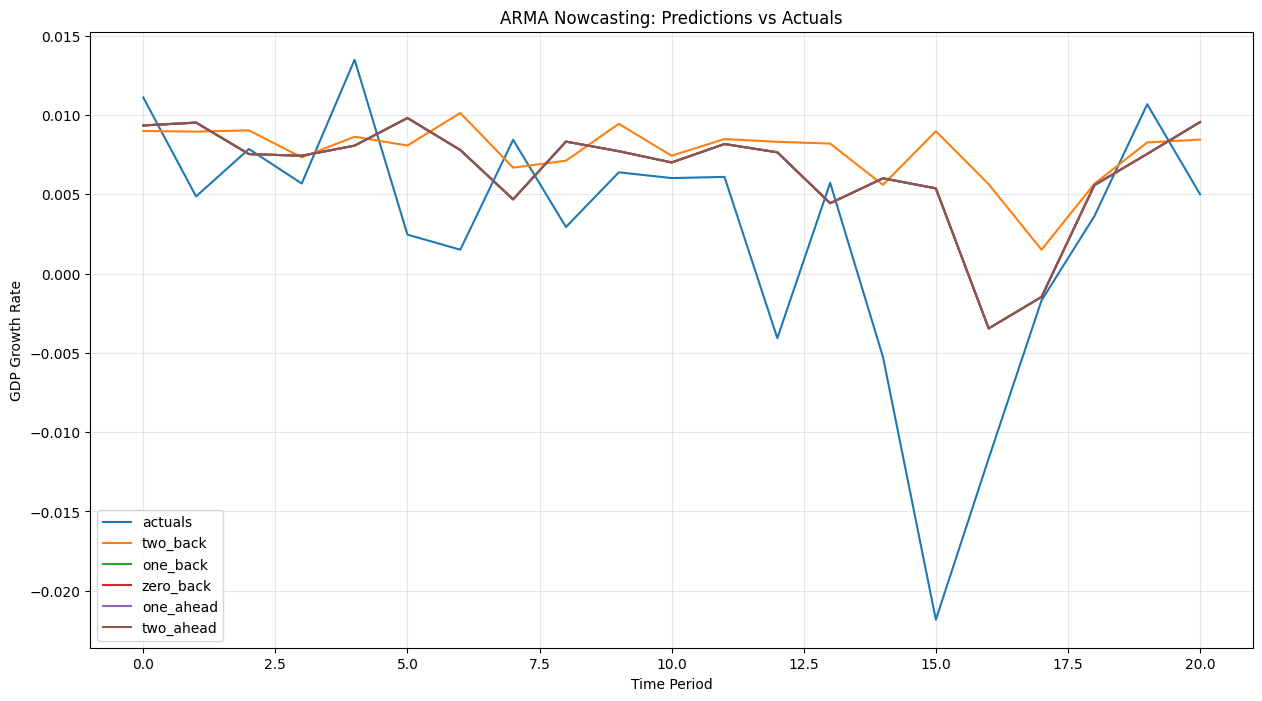

In [8]:
# Plot predictions vs actuals
pd.DataFrame({
    "actuals": actuals,
    "two_back": pred_dict[-2],
    "one_back": pred_dict[-1],
    "zero_back": pred_dict[0],
    "one_ahead": pred_dict[1],
    "two_ahead": pred_dict[2]
}).plot(title="ARMA Nowcasting: Predictions vs Actuals", figsize=(15, 8))
plt.ylabel("GDP Growth Rate")
plt.xlabel("Time Period")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Inference on New Data

In [9]:
# Prepare for new prediction
new_data = test.copy()
ts_subset = new_data.loc[~pd.isna(new_data[target_variable])].copy()
ts_series = ts_subset.set_index("date")[target_variable]
ts_series.index = pd.DatetimeIndex(ts_series.index)
if ts_series.index.freq is None:
    ts_series.index.freq = pd.infer_freq(ts_series.index)

print(f"Time series length: {len(ts_series)}")
print(f"Last observation: {ts_series.index[-1]}")

# Fit and predict
ts_model = pm.arima.ARIMA((ar_order, 0, ma_order), suppress_warnings=True)
preds = ts_model.fit_predict(ts_series, n_periods=10)

# Get prediction for 2010-06-01 (first period ahead)
prediction = preds.to_list()[0]
print(f"\nPrediction for 2010-06-01: {prediction:.4f}")

Time series length: 252
Last observation: 2010-03-01 00:00:00

Prediction for 2010-06-01: 0.0080

Prediction for 2010-06-01: 0.0080


## Summary

This notebook implements a univariate ARMA model as a baseline for GDP nowcasting. The ARMA model uses only the historical GDP series to make predictions, without incorporating any external variables or high-frequency indicators.

The optimal ARMA order is automatically selected using the auto_arima function from pmdarima, which searches over different combinations and selects based on AIC. The model is estimated on a rolling basis, training only on data available at each point in time to simulate real-world forecasting conditions.

As a univariate model, ARMA serves as a simple baseline for comparison with more sophisticated multivariate approaches. It typically performs reasonably well in stable periods but has limited capability during economic shocks or structural changes, as it cannot incorporate additional information signals from other economic indicators.